In [696]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [697]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix


In [698]:
path = "Datasets/liver_patient_dataset.csv"
df = pd.read_csv(path)

In [699]:
df.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Liver Disease
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Liver Disease
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Liver Disease
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Liver Disease
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Liver Disease


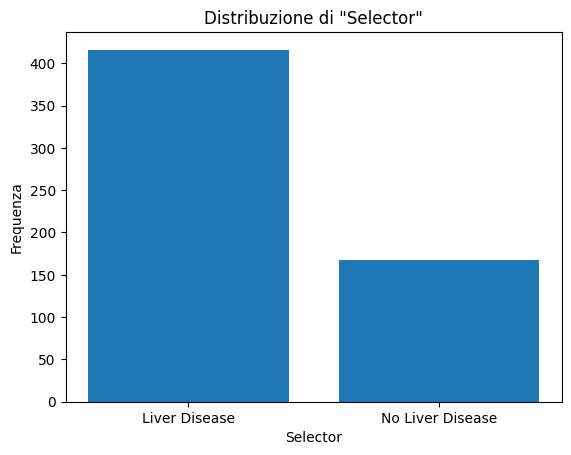

In [700]:
conteggi = df["Selector"].value_counts()

plt.bar(conteggi.index, conteggi.values)
plt.xlabel("Selector")
plt.ylabel("Frequenza")
plt.title('Distribuzione di "Selector"')
plt.show()

In [701]:
feature_names = set(df.columns) - set(["Selector"])

target_name = "Selector"

categorical_features = set(["Gender"])
continuos_features = feature_names - set(["Gender"])

print(categorical_features)
print(continuos_features)
feature_names = list(feature_names)

{'Gender'}
{'Sgpt', 'A/G Ratio', 'TB', 'DB', 'ALB', 'Sgot', 'Alkphos', 'Age', 'TP'}


In [702]:
df_encoded = df.copy()

df_encoded["Gender"] = df_encoded["Gender"].astype("category").cat.codes
df_encoded["Selector"] = df_encoded["Selector"].astype("category").cat.codes

In [703]:
y = df_encoded["Selector"]
X_train, X_test, y_train, y_test = train_test_split(df_encoded[feature_names], df_encoded[target_name], test_size=0.3, random_state=42, stratify=y)

In [704]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# separo feature e target
X = X_train
y = y_train

# scrivi qui le colonne categoriche
categoriche = ["Gender"]

# True per le categoriche, False per le continue
discrete_mask = []

for col in X.columns:
    if col in categoriche:
        discrete_mask.append(True)
    else:
        discrete_mask.append(False)

# calcolo mutual information
mi = mutual_info_classif(
    X,
    y,
    discrete_features=discrete_mask,
    random_state=42
)

# creo tabella ordinata
importanza_variabili = pd.DataFrame({
    "variabile": X.columns,
    "importanza": mi
})

importanza_variabili = importanza_variabili.sort_values(
    by="importanza",
    ascending=False
)

print(importanza_variabili)

   variabile  importanza
0       Sgpt    0.096307
4         DB    0.078471
3         TB    0.038618
8        Age    0.029116
1  A/G Ratio    0.028480
7    Alkphos    0.026975
6       Sgot    0.026660
5        ALB    0.009040
2     Gender    0.002729
9         TP    0.000000


In [ ]:
# alternativa a MI, PERMUTATION IMPORTANCE, dove addestro il modello mischiando una feature per volta e vede come variano le performance


from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

# ======================
# 1. ALLENAMENTO MODELLO
# ======================
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# ======================
# 2. PERMUTATION IMPORTANCE
# ======================
result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="accuracy"   # puoi cambiare in f1, roc_auc, ecc.
)

# ======================
# 3. TABELLA RISULTATI
# ======================
importanza_variabili = pd.DataFrame({
    "variabile": X_test.columns,
    "importanza_media": result.importances_mean,
    "importanza_std": result.importances_std
})

importanza_variabili = importanza_variabili.sort_values(
    by="importanza_media",
    ascending=False
)

print(importanza_variabili)

   variabile  importanza_media  importanza_std
4         DB          0.042286        0.021563
8        Age          0.030286        0.013291
0       Sgpt          0.020571        0.011486
7    Alkphos          0.012000        0.016650
1  A/G Ratio          0.009714        0.021081
2     Gender          0.008000        0.002799
6       Sgot          0.004571        0.008778
5        ALB         -0.002857        0.016413
3         TB         -0.006286        0.004747
9         TP         -0.008000        0.020316


In [706]:
model = DecisionTreeClassifier(random_state=42, max_depth=3)
model = model.fit(X_train, y_train)

# Visualizza l'albero decisionale
fig, ax = plt.subplots(figsize=(150, 100))
plot_tree(model, filled=True, ax=ax)
plt.plot()

[]

In [707]:
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)
print("\nAccuracy:", cm.diagonal().sum() / cm.sum())

Confusion matrix:
 [[107  18]
 [ 38  12]]

Accuracy: 0.68


In [708]:
import numpy as np
import pandas as pd

# NUOVA FUNZIONE CHE AGGIUNGE RIGHE INVECE DI MODIFICARNE ALTRE

def add_dirty_rows(X, y, cat_cols, cont_cols, frac=0.1, noise_level=0.1, random_state=None):
    rng = np.random.default_rng(random_state)

    n_rows_to_add = int(frac * len(X))
    if n_rows_to_add == 0:
        print("Attenzione: frac troppo bassa, nessuna riga aggiunta.")
        return X.copy(), y.copy()

    # Scelgo gli indici sorgente — stessi per X e y, così rimangono allineati
    source_indices = rng.choice(X.index, size=n_rows_to_add, replace=True)

    new_X = X.loc[source_indices].copy().reset_index(drop=True)
    new_y = y.loc[source_indices].copy().reset_index(drop=True)

    # ------- Corrompo le colonne categoriche -------
    for col in cat_cols:
        if col not in new_X.columns:
            print(f"Attenzione: colonna '{col}' non trovata. Saltata.")
            continue
        unique_values = X[col].unique()
        if len(unique_values) <= 1:
            print(f"Attenzione: '{col}' ha un solo valore unico. Saltata.")
            continue
        for i in range(len(new_X)):
            current = new_X.at[i, col]
            pool = unique_values[unique_values != current]
            new_X.at[i, col] = rng.choice(pool)

    # ------- Corrompo le colonne continue -------
    for col in cont_cols:
        if col not in new_X.columns:
            print(f"Attenzione: colonna '{col}' non trovata. Saltata.")
            continue
        new_X[col] = new_X[col].astype(float)
        std_col = X[col].std()
        if std_col == 0:
            print(f"Attenzione: '{col}' ha deviazione standard 0. Saltata.")
            continue
        noise = rng.normal(loc=0, scale=noise_level * std_col, size=len(new_X))
        new_X[col] = new_X[col] + noise

    # ------- Unisco e resetto l'indice -------
    X_augmented = pd.concat([X.copy(), new_X], ignore_index=True)
    y_augmented = pd.concat([y.copy(), new_y], ignore_index=True)

    return X_augmented, y_augmented

In [709]:
X_train_dirty, y_train_dirty = add_dirty_rows(
    X_train, y_train,
    cat_cols  = [],
    cont_cols = ['TB'],
    frac         = 0.1,
    noise_level  = 1,
    random_state = 42
)

print(f"Righe originali : {len(X_train)}")
print(f"Righe aumentate : {len(X_train_dirty)}")

X_train_dirty.head()

Righe originali : 408
Righe aumentate : 448


,Sgpt,A/G Ratio,Gender,TB,DB,ALB,Sgot,Alkphos,Age,TP
0,44,0.30,1,7.3,3.7,1.6,236,92,50,6.8
1,24,1.00,1,0.8,0.2,3.2,20,140,45,6.3
2,14,1.00,1,1.0,0.4,3.4,20,182,58,6.8
3,36,1.55,1,0.9,0.2,4.2,45,224,17,6.9
4,43,1.20,1,0.8,0.2,4.0,31,198,31,7.3


In [710]:
model = DecisionTreeClassifier(random_state=42, max_depth=3)
model = model.fit(X_train_dirty, y_train_dirty)

# Visualizza l'albero decisionale
fig, ax = plt.subplots(figsize=(150, 100))
plot_tree(model, filled=True, ax=ax)
plt.plot()

[]

In [711]:
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)
print("\nAccuracy:", cm.diagonal().sum() / cm.sum())

Confusion matrix:
 [[116   9]
 [ 41   9]]

Accuracy: 0.7142857142857143


Noise   0% → Accuracy: 0.6800  (righe train: 408)
Noise  10% → Accuracy: 0.6343  (righe train: 448)
Noise  20% → Accuracy: 0.6800  (righe train: 489)
Noise  30% → Accuracy: 0.6800  (righe train: 530)
Noise  40% → Accuracy: 0.6400  (righe train: 571)
Noise  50% → Accuracy: 0.6857  (righe train: 612)
Noise  60% → Accuracy: 0.6800  (righe train: 652)
Noise  70% → Accuracy: 0.7143  (righe train: 693)
Noise  80% → Accuracy: 0.6343  (righe train: 734)
Noise  90% → Accuracy: 0.6914  (righe train: 775)
Noise 100% → Accuracy: 0.7029  (righe train: 816)


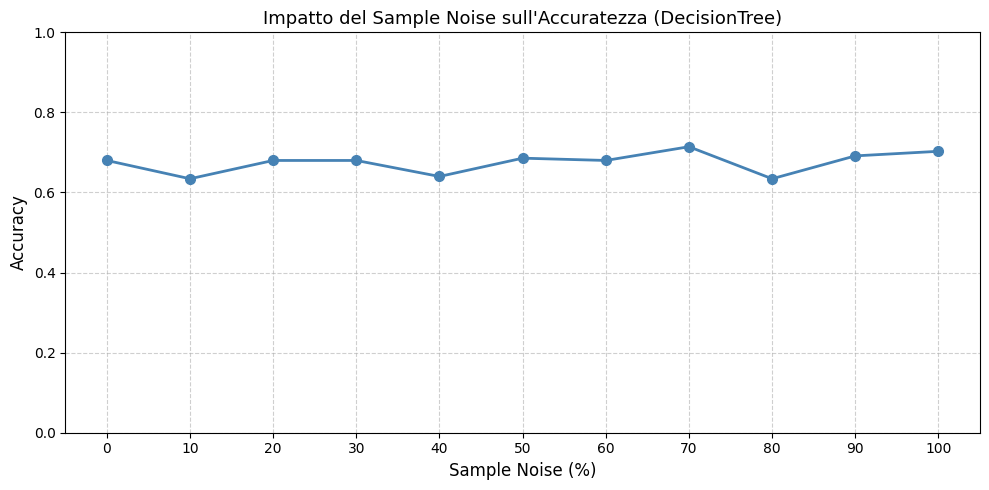

In [712]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

# Percentuali di rumore da testare (0%, 10%, 20%, ..., 100%)
noise_fracs = [i / 10 for i in range(0, 11)]

noise_level = 0.5

# Colonne da modificare
cat_cols_noise  = ['Gender']
cont_cols_noise = ['Sgpt', 'A/G Ratio', 'TB', 'DB', 'ALB', 'Sgot', 'Alkphos', 'Age', 'TP']

accuracies = []

for frac in noise_fracs:
    if frac == 0:
        X_noisy, y_noisy = X_train.copy(), y_train.copy()
    else:
        X_noisy, y_noisy = add_dirty_rows(
            X_train, y_train,
            cat_cols=cat_cols_noise,
            cont_cols=cont_cols_noise,
            frac=frac,
            noise_level=noise_level,
            random_state=42
        )

    clf = DecisionTreeClassifier(random_state=42, max_depth=3)
    clf.fit(X_noisy, y_noisy)
    y_pred = clf.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    acc = cm.diagonal().sum() / cm.sum()
    accuracies.append(acc)
    print(f"Noise {int(frac*100):3d}% → Accuracy: {acc:.4f}  (righe train: {len(X_noisy)})")

# --- Grafico ---
plt.figure(figsize=(10, 5))
plt.plot([int(f * 100) for f in noise_fracs], accuracies,
         marker='o', color='steelblue', linewidth=2, markersize=7)
plt.xlabel("Sample Noise (%)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Impatto del Sample Noise sull'Accuratezza (DecisionTree)", fontsize=13)
plt.xticks([int(f * 100) for f in noise_fracs])
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()